In [2]:
# ============================================================
# Cell 1: Imports & Setup
# ============================================================

# Python Standard Libraries
import os                       # os.getcwd(), os.path.join()

# External Libraries
import numpy as np              # np.array(), np.mean(), np.std()
import matplotlib.pyplot as plt # plt.imread(),plt.imshow(), plt.show(), plt.axis('off'),
import pandas as pd             
import cv2                      # cv2.imread(), cv2.cvtColor(), cv2.COLOR_BGR2RGB, cv2.COLOR_BGR2HSV, cv2.COLOR_BGR2LAB, cv2.COLOR_BGR2YCrCb


# Pytorch Libraries
import torch
import torch.nn as nn

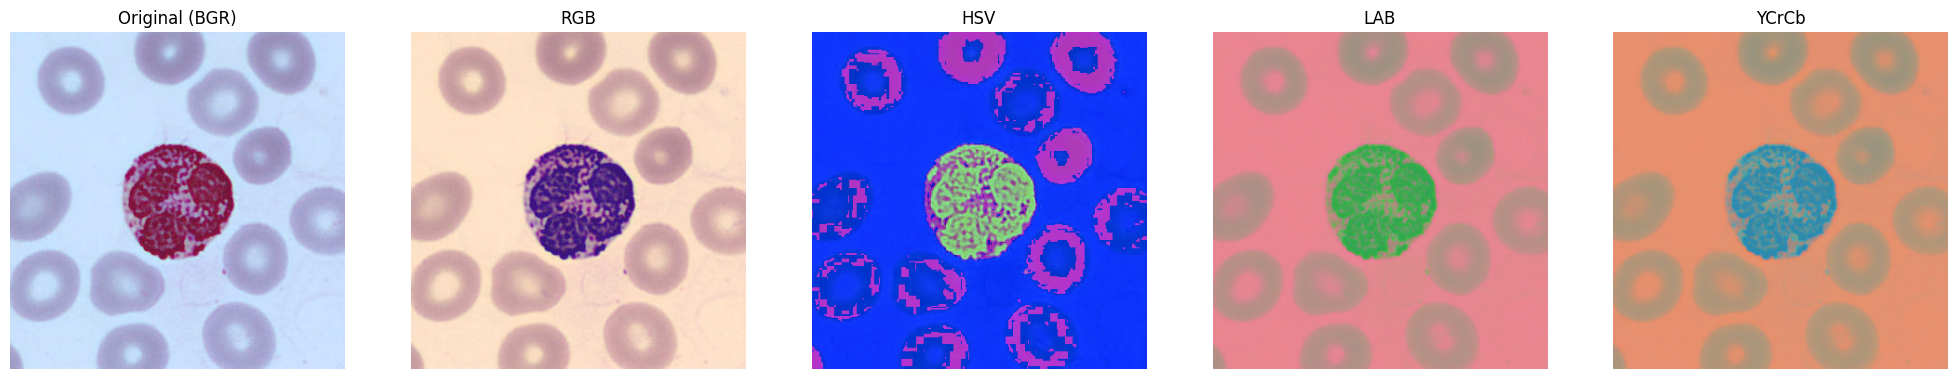

C:\Users\User1\Documents\GitHub\IIP-G8\Misc Files\Naturalize Dataset\Naturalize Dataset\BA\BA 2k-PBC Train (24).jpg
C:\Users\User1\Documents\GitHub\IIP-G8\Misc Files\Naturalize Dataset\Naturalize Dataset
c:\Users\User1\Documents\GitHub\IIP-G8


In [58]:
# Image Color Space Check
ROOT_DIR = r"C:\Users\User1\Documents\GitHub\IIP-G8\Misc Files\Naturalize Dataset\Naturalize Dataset"
FILE_DIR = os.getcwd()

TEST_IMG = os.path.join(ROOT_DIR, r"BA\BA 2k-PBC Train (24).jpg")
img = cv2.imread(TEST_IMG)

"""
Function show_colorspace_image: Prepares images to be displayed for plt.show() call.
    Parameters:
    - number: Number it sequentially from 0-n.
    - image: Pass img or the base image (remember to convert from its respective color space).
    - title: Title of converted color space.
    - color_model: Color space chosen.
"""
def show_colorspace_image(number, image, title, color_model):
    if color_model is not None:
            image = cv2.cvtColor(image, color_model)
    axes[number].imshow(image)
    axes[number].set_title(title)
    axes[number].axis('off')

# Figure Creation
figs, axes = plt.subplots(1, 5, figsize=(25, 5))

show_colorspace_image(0, img, "Original (BGR)", None)
show_colorspace_image(1, img, "RGB", cv2.COLOR_BGR2RGB)
show_colorspace_image(2, img, "HSV", cv2.COLOR_BGR2HSV)
show_colorspace_image(3, img, "LAB", cv2.COLOR_BGR2LAB)
show_colorspace_image(4, img, "YCrCb", cv2.COLOR_BGR2YCrCb)

plt.show()


# Root Checks
print(TEST_IMG)
print(ROOT_DIR)
print(FILE_DIR)

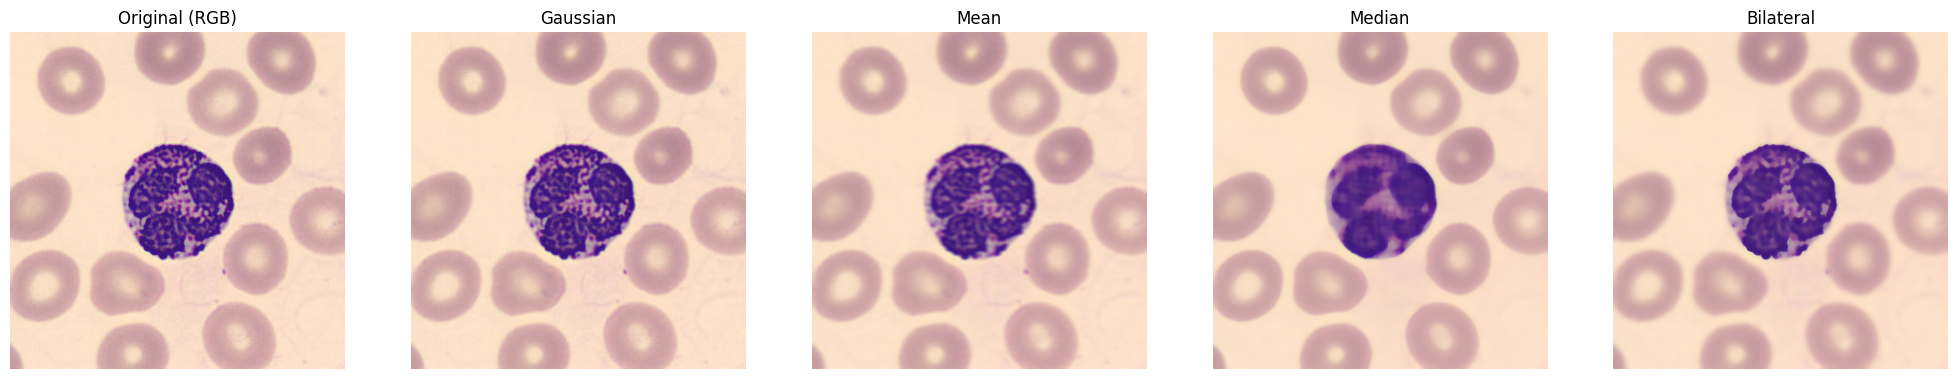

In [ ]:

# Convert the original BGR image to RGB so it looks correct in matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

"""
Function show_filtered_image: Prepares images to be displayed for plt.show() call.
    Parameters:
    - number: Number it sequentially from 0-n.
    - image: The base image to apply the filter to.
    - title: Title of the filter.
    - filter_type: Type of noise reduction filter to apply.
"""
def show_filtered_image(number, image, title, filter_type=None):
    if filter_type == "gaussian":
        """
        cv2.GaussianBlur(src, ksize, sigmaX)
        ksize = Kernel Size (Linear dimensions for the square window used to calculate the median value. - Only ODD Positive Numbers).
        sigmaX = Std. Dev. for gaussian dist. across X-axis. (bigger = more blurring)
        """
        image = cv2.GaussianBlur(image, (11, 11), 0.5)

    elif filter_type == "mean":
        # cv2.blur(src, ksize)
        image = cv2.blur(image, (5, 3))

    elif filter_type == "median":
        # cv2.medianBlur(src, ksize).
        image = cv2.medianBlur(image, 11)

    elif filter_type == "bilateral":
        """ 
        cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)
        d = Diameter of Neighborhood (defines how large the area is around each pixel that is considered for the blurring calculation.)
        signaColor = determines how dissimilar colors/intensities can be before they are ignored during the filtering process.
        sigmaSpace = Same as sigmaColor but for spatial coordinates/space.
        """ 
        image = cv2.bilateralFilter(image, 9, 110, 30)
        
    axes[number].imshow(image)
    axes[number].set_title(title)
    axes[number].axis('off')
    
# Figure Creation
figs, axes = plt.subplots(1, 5, figsize=(25, 5))

show_filtered_image(0, img_rgb, "Original (RGB)", None)
show_filtered_image(1, img_rgb, "Gaussian", "gaussian")
show_filtered_image(2, img_rgb, "Mean", "mean")
show_filtered_image(3, img_rgb, "Median", "median")
show_filtered_image(4, img_rgb, "Bilateral", "bilateral")

plt.show()